# Solution 16: Focal Loss + 40K + Hybrid TTA

Built on Solution 14 with three changes: focal loss (gamma=2.0) to downweight easy samples, doubled the dataset to 40K (TARGET_PER_TYPE from 5,000 to 10,000), and hybrid TTA at inference (single-pass for 2-choice where TTA hurts, full TTA for 3/4/5-choice).

Despite the extra data and targeted loss, the focal loss didn't help. Score came in at 0.91348, below Solution 14's 0.91549.

**Kaggle Score: 0.91348**

## 0. Install Dependencies

In [1]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.3 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.1 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.19.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports & Configuration

In [13]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re, random, copy, math
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from itertools import permutations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v20"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v20"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 18
LORA_ALPHA = 36
LORA_DROPOUT = 0.05

IMAGE_LONGEST_EDGE = 512

LEARNING_RATE = 2e-4
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 5
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA = 2.0
SEED = 42

TARGET_PER_TYPE = 10000

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
print(f"\nv20 changes vs v16:")
print(f"  Focal loss gamma: {FOCAL_GAMMA} (was standard CE)")
print(f"  Dataset: 40K (was 20K)")
print(f"  Inference: Hybrid TTA (SP for 2-choice, TTA for 3/4/5)")

transformers: 4.47.0
Device: cuda

v20 changes vs v16:
  Focal loss gamma: 2.0 (was standard CE)
  Dataset: 40K (was 20K)
  Inference: Hybrid TTA (SP for 2-choice, TTA for 3/4/5)


## 2. Load Data & Balanced Factorial Augmentation (40K)

In [4]:
train_df_orig = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Original Train: {len(train_df_orig)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nOriginal distribution by num_choices:")
print(train_df_orig['num_choices'].value_counts().sort_index())

def apply_permutation(row, perm):
    """Apply a specific permutation to choices and remap answer."""
    choices = json.loads(row['choices'])
    answer = int(row['answer'])
    new_choices = [choices[perm[i]] for i in range(len(perm))]
    new_answer = list(perm).index(answer)
    new_row = row.copy()
    new_row['choices'] = json.dumps(new_choices)
    new_row['answer'] = new_answer
    return new_row

rng = random.Random(SEED)
shuffled_rows = []

for nc in [2, 3, 4, 5]:
    subset = train_df_orig[train_df_orig['num_choices'] == nc]
    n_base = len(subset)
    n_perms = math.factorial(nc)
    all_perms = list(permutations(range(nc)))

    ppq = TARGET_PER_TYPE / n_base
    k_floor = int(ppq)
    k_ceil = k_floor + 1
    n_ceil = TARGET_PER_TYPE - n_base * k_floor
    n_floor = n_base - n_ceil

    count = 0
    for q_idx, (_, row) in enumerate(subset.iterrows()):
        k = k_ceil if q_idx < n_ceil else k_floor

        if k <= n_perms:
            selected_perms = rng.sample(all_perms, k)
        else:
            full_rounds = k // n_perms
            remainder = k % n_perms
            selected_perms = all_perms * full_rounds
            if remainder > 0:
                selected_perms += rng.sample(all_perms, remainder)

        for perm in selected_perms:
            shuffled_rows.append(apply_permutation(row, perm))
            count += 1

    print(f"  {nc}-choice: {n_base} base -> {count} samples (target: {TARGET_PER_TYPE})")

train_df = pd.DataFrame(shuffled_rows).reset_index(drop=True)

print(f"\nTotal augmented train: {len(train_df)}")
print(f"\nAnswer distribution (should be ~uniform):")
for nc in [2, 3, 4, 5]:
    sub = train_df[train_df['num_choices'] == nc]
    dist = sub['answer'].value_counts().sort_index()
    print(f"  {nc}-choice: {dict(dist)}")

for i in random.sample(range(len(train_df)), 100):
    row = train_df.iloc[i]
    orig = train_df_orig[train_df_orig['id'] == row['id']].iloc[0]
    oc = json.loads(orig['choices'])
    sc = json.loads(row['choices'])
    assert oc[int(orig['answer'])] == sc[int(row['answer'])], f"SHUFFLE BUG at {row['id']}!"
print(f"  100 random spot checks passed!")

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"\nImages accessible at {IMG_BASE}")

Original Train: 3109 | Val: 1048 | Test: 1008

Original distribution by num_choices:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64
  2-choice: 664 base -> 10000 samples (target: 10000)
  3-choice: 1552 base -> 10000 samples (target: 10000)
  4-choice: 783 base -> 10000 samples (target: 10000)
  5-choice: 110 base -> 10000 samples (target: 10000)

Total augmented train: 40000

Answer distribution (should be ~uniform):
  2-choice: {0: np.int64(4995), 1: np.int64(5005)}
  3-choice: {0: np.int64(3349), 1: np.int64(3306), 2: np.int64(3345)}
  4-choice: {0: np.int64(2469), 1: np.int64(2546), 2: np.int64(2503), 3: np.int64(2482)}
  5-choice: {0: np.int64(2014), 1: np.int64(2041), 2: np.int64(1996), 3: np.int64(1981), 4: np.int64(1968)}
  100 random spot checks passed!

Images accessible at /content/drive/MyDrive/pixels-to-predictions/images


## 3. Load Model & Processor

In [5]:
MODEL_CACHE_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v16/base_model_cache"
PROCESSOR_CACHE_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v16/processor_cache"

if os.path.exists(os.path.join(MODEL_CACHE_DIR, "config.json")):
    print("Loading base model from Drive cache...")
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_CACHE_DIR, torch_dtype=torch.float16, device_map="auto")
    processor = AutoProcessor.from_pretrained(PROCESSOR_CACHE_DIR)
else:
    print("Downloading base model from HuggingFace...")
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto")

processor.image_processor.size = {"longest_edge": IMAGE_LONGEST_EDGE}

print(f"Image processor size: {processor.image_processor.size}")
print(f"Image seq len: {processor.image_seq_len}")
print(f"Model type: {type(model).__name__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Image processor size: {'longest_edge': 512}
Image seq len: 64
Model type: Idefics3ForConditionalGeneration


## 4. Apply LoRA + DoRA

In [6]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.CAUSAL_LM,
    bias="none",
    use_dora=True,
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")
print(f"DoRA enabled: {lora_config.use_dora}")
print(f"Targets: {lora_config.target_modules}")

Trainable parameters: 4,791,296 (4.79M)
Total parameters:     512,273,600 (512.3M)
Trainable %:          0.94%

Under 5M cap (4,791,296 <= 5,000,000)
DoRA enabled: True
Targets: {'q_proj', 'v_proj', 'k_proj', 'o_proj'}


## 5. Prompt & Dataset

In [7]:
def build_prompt(row, include_answer=False):
    """Identical to v16."""
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []
    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

class ScienceVQADataset(Dataset):
    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 40000 | Val: 1048 | Test: 1008


## 6. DataLoaders

In [8]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(2, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    print(f"  Sample {i}: '{decoded.strip()}'")

Train batches: 5000 | Val batches: 131
Effective batch size: 16

input_ids: torch.Size([8, 739])
pixel_values: torch.Size([8, 1, 3, 512, 512])
  Sample 0: '0<end_of_utterance>'
  Sample 1: '1<end_of_utterance>'


## 7. Focal Loss Definition

In [9]:
class FocalLoss(nn.Module):
    """Focal Loss with label smoothing.

    Focal loss downweights easy (high-confidence) samples and focuses on hard ones.
    With gamma=0, reduces to standard cross-entropy.
    With gamma=2 (default), hard samples get much more weight than easy ones.

    Effect on our task:
    - 5-choice questions (acc=54%) are hard -> get MORE weight
    - 3-choice questions (acc=93%) are easy -> get LESS weight
    - Model focuses learning budget on what it's worst at
    """
    def __init__(self, gamma=2.0, label_smoothing=0.1, ignore_index=-100):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        mask = targets != self.ignore_index
        logits = logits[mask]
        targets = targets[mask]

        if logits.numel() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)

        num_classes = logits.size(-1)

        log_probs = F.log_softmax(logits, dim=-1)

        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, self.label_smoothing / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        ce_loss = -(smooth_targets * log_probs).sum(dim=-1)

        with torch.no_grad():
            probs = torch.softmax(logits, dim=-1)
            p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
            focal_weight = (1 - p_t) ** self.gamma

        loss = (focal_weight * ce_loss).mean()
        return loss

def compute_loss(logits, labels):
    """Shift logits/labels for next-token prediction, apply focal loss."""
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    shift_logits = shift_logits.view(-1, shift_logits.size(-1))
    shift_labels = shift_labels.view(-1)
    return focal_loss_fn(shift_logits, shift_labels)

focal_loss_fn = FocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
print(f"Loss: Focal Loss (gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING})")
print(f"\nFocal weighting effect:")
print(f"  p=0.9 (easy/confident): weight = {(1-0.9)**FOCAL_GAMMA:.4f} (downweighted 100x)")
print(f"  p=0.5 (uncertain):      weight = {(1-0.5)**FOCAL_GAMMA:.4f}")
print(f"  p=0.2 (hard/wrong):     weight = {(1-0.2)**FOCAL_GAMMA:.4f} (full weight)")

Loss: Focal Loss (gamma=2.0, label_smoothing=0.1)

Focal weighting effect:
  p=0.9 (easy/confident): weight = 0.0100 (downweighted 100x)
  p=0.5 (uncertain):      weight = 0.2500
  p=0.2 (hard/wrong):     weight = 0.6400 (full weight)


## 8. Training Loop

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Steps per epoch: {len(train_loader) // GRAD_ACCUM_STEPS}")
print(f"Loss: Focal (gamma={FOCAL_GAMMA}) + Label Smoothing ({LABEL_SMOOTHING})")

Total steps: 15000 | Warmup: 1500
Steps per epoch: 2500
Loss: Focal (gamma=2.0) + Label Smoothing (0.1)


In [11]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
        total_loss += loss.item()
        num_batches += 1

        logits = outputs.logits
        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)

has_checkpoint = os.path.exists(os.path.join(CKPT_DIR, "training_state.pt"))
if not has_checkpoint:
    print("Pre-training evaluation...")
    val_loss, val_acc = evaluate(model, val_loader, processor)
    print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
else:
    print("Checkpoint found — skipping pre-training eval")

Pre-training evaluation...


Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]

Pre-training — Val Loss: 2.3619 | Val Acc: 0.4895


In [14]:
def save_epoch_checkpoint(model, processor, epoch, ckpt_dir):
    """Save adapter for this specific epoch (never overwritten)."""
    epoch_dir = os.path.join(ckpt_dir, f"epoch_{epoch+1}")
    os.makedirs(epoch_dir, exist_ok=True)
    model.save_pretrained(epoch_dir)
    processor.save_pretrained(epoch_dir)
    print(f"  Epoch {epoch+1} adapter saved to {epoch_dir}")

def save_training_state(model, optimizer, scheduler, scaler, epoch, step,
                        best_val_acc, train_losses, val_losses, val_accs, path):
    """Save latest training state for resume."""
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Training state saved to {path}")

def load_training_state(model, optimizer, scheduler, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)

    if os.path.exists(adapter_path):
        from peft import set_peft_model_state_dict
        from safetensors.torch import load_file
        adapter_weights_path = os.path.join(adapter_path, "adapter_model.safetensors")
        if os.path.exists(adapter_weights_path):
            adapter_state = load_file(adapter_weights_path)
            set_peft_model_state_dict(model, adapter_state)
            print(f"  Loaded adapter weights from {adapter_path}")

    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])

    print(f"  Resumed from epoch {state['epoch']}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_training_state(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
    if val_losses:
        best_val_loss = min(val_losses)
        best_loss_epoch = val_losses.index(best_val_loss) + 1
    else:
        best_val_loss = float('inf')
        best_loss_epoch = 0
else:
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_loss_epoch = 0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 500 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    save_epoch_checkpoint(model, processor, epoch, CKPT_DIR)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  New best val acc! Saved to {OUTPUT_DIR}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_loss_epoch = epoch + 1
        best_loss_dir = os.path.join(CKPT_DIR, "best_val_loss")
        os.makedirs(best_loss_dir, exist_ok=True)
        model.save_pretrained(best_loss_dir)
        processor.save_pretrained(best_loss_dir)
        print(f"  New best val loss! Saved to {best_loss_dir}")

    save_training_state(model, optimizer, scheduler, scaler, epoch + 1, 0,
                        best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*50}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f} (epoch {best_loss_epoch})")
print(f"\nPer-epoch results:")
for i in range(len(train_losses)):
    marker = ""
    if val_accs[i] == best_val_acc:
        marker += " <- best acc"
    if val_losses[i] == best_val_loss:
        marker += " <- best loss"
    print(f"  E{i+1}: train={train_losses[i]:.4f} val_loss={val_losses[i]:.4f} val_acc={val_accs[i]:.4f}{marker}")

  Loaded adapter weights from /content/drive/MyDrive/pixels-to-predictions/checkpoints_v20/lora_adapter
  Resumed from epoch 5, best_acc=0.9046
Resuming from epoch 6

Best Val Accuracy: 0.9046
Best Val Loss: 0.2059 (epoch 3)

Per-epoch results:
  E1: train=0.3438 val_loss=0.2289 val_acc=0.8397
  E2: train=0.0528 val_loss=0.2335 val_acc=0.8788
  E3: train=0.0278 val_loss=0.2059 val_acc=0.9046 <- best acc <- best loss
  E4: train=0.0216 val_loss=0.2202 val_acc=0.8989
  E5: train=0.0166 val_loss=0.2599 val_acc=0.9027


## 9. Training Curves

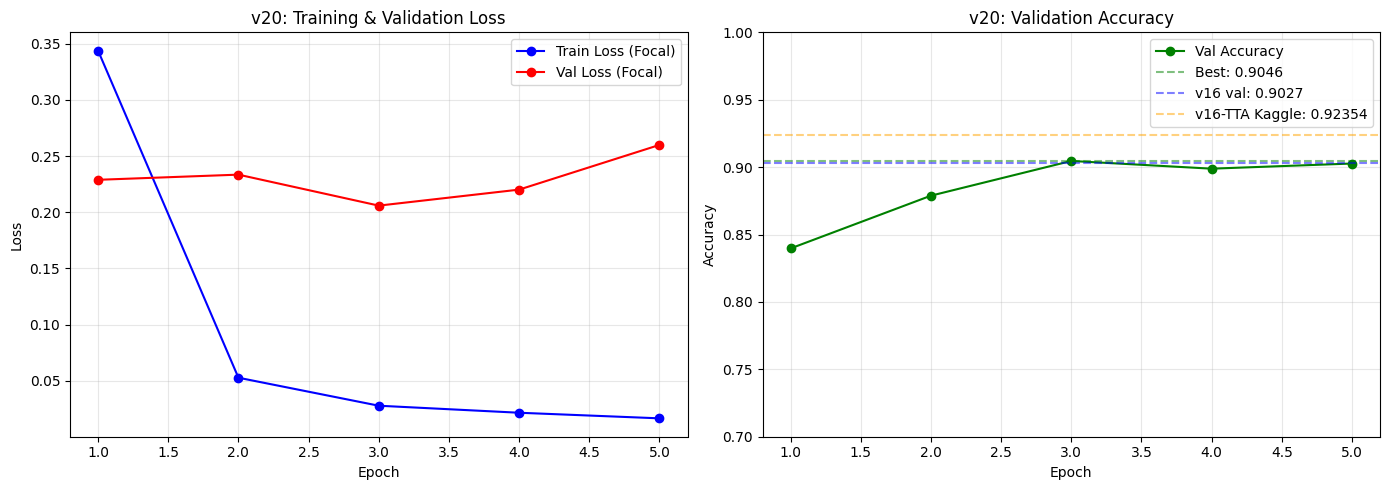

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss (Focal)')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss (Focal)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('v20: Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.9027, color='blue', linestyle='--', alpha=0.5, label='v16 val: 0.9027')
ax2.axhline(y=0.92354, color='orange', linestyle='--', alpha=0.5, label='v16-TTA Kaggle: 0.92354')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('v20: Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.7, 1)

plt.tight_layout()
plt.show()

## 10. Load Best Model for Inference

In [16]:
best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

del model
torch.cuda.empty_cache()

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()

print(f"Loaded best model from {best_adapter_path}")
print(f"Image resolution: {processor.image_processor.size}")

Loaded best model from /content/smolvlm-lora-v20
Image resolution: {'longest_edge': 512}


## 11. Hybrid TTA Inference

Based on Solution 15's validation analysis:
- 2-choice: single-pass only (TTA hurts by -1.64%)
- 3/4/5-choice: full TTA (helps by +0.4%, +4.0%, +2.3%)

In [17]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")

@torch.no_grad()
def predict_single_pass(model, processor, df, img_base, batch_size=4):
    """Standard single-pass digit logit prediction."""
    model.eval()
    all_ids, all_preds = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Single-pass"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds

@torch.no_grad()
def predict_tta(model, processor, df, img_base, batch_size=4):
    """TTA: run all N! choice permutations, average logits mapped to original positions."""
    model.eval()
    all_ids, all_preds = [], []

    for idx in tqdm(range(len(df)), desc="TTA"):
        row = df.iloc[idx]
        nc = row['num_choices']
        choices = json.loads(row['choices'])
        all_perms = list(permutations(range(nc)))
        original_scores = torch.zeros(nc, device=device)
        image = Image.open(os.path.join(img_base, row['image_path'])).convert("RGB")

        for perm_start in range(0, len(all_perms), batch_size):
            perm_batch = all_perms[perm_start:perm_start + batch_size]
            images, texts, perms = [], [], []

            for perm in perm_batch:
                perm_row = row.copy()
                perm_row['choices'] = json.dumps([choices[perm[i]] for i in range(nc)])
                prompt = build_prompt(perm_row, include_answer=False)
                messages = [{"role": "user", "content": [
                    {"type": "image"}, {"type": "text", "text": prompt}]}]
                texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
                images.append(image.copy())
                perms.append(perm)

            inputs = processor(text=texts, images=images, return_tensors="pt",
                             padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

            with torch.amp.autocast("cuda", dtype=torch.float16):
                outputs = model(**inputs)
            logits = outputs.logits

            for i, perm in enumerate(perms):
                last_pos = inputs["attention_mask"][i].sum().item() - 1
                next_logits = logits[i, last_pos, :]
                digit_scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
                for d in range(nc):
                    original_scores[perm[d]] += digit_scores[d]

        pred = original_scores.argmax().item()
        all_preds.append(pred)
        all_ids.append(row['id'])

    return all_ids, all_preds

@torch.no_grad()
def predict_hybrid_tta(model, processor, df, img_base, batch_size=4):
    """Hybrid TTA: single-pass for 2-choice, full TTA for 3/4/5-choice.

    Based on v16-TTA analysis:
      2-choice: TTA hurts (-1.64%), use single-pass
      3-choice: TTA helps (+0.39%), use TTA
      4-choice: TTA helps (+3.97%), use TTA
      5-choice: TTA helps (+2.27%), use TTA
    """
    model.eval()

    df_2 = df[df['num_choices'] == 2].reset_index(drop=True)
    df_345 = df[df['num_choices'] >= 3].reset_index(drop=True)

    print(f"  2-choice (single-pass): {len(df_2)} questions")
    print(f"  3/4/5-choice (TTA): {len(df_345)} questions")

    ids_2, preds_2 = [], []
    if len(df_2) > 0:
        ids_2, preds_2 = predict_single_pass(model, processor, df_2, img_base, batch_size)

    ids_345, preds_345 = [], []
    if len(df_345) > 0:
        ids_345, preds_345 = predict_tta(model, processor, df_345, img_base, batch_size)

    all_ids = ids_2 + ids_345
    all_preds = preds_2 + preds_345

    return all_ids, all_preds

print("Prediction functions defined (single-pass, TTA, hybrid TTA).")

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}
Prediction functions defined (single-pass, TTA, hybrid TTA).


## 12. Validation: Compare All Methods

In [18]:
print("=== Single-Pass ===\n")
val_ids_sp, val_preds_sp = predict_single_pass(model, processor, val_df, IMG_BASE, batch_size=4)
val_acc_sp = np.mean([p == a for p, a in zip(val_preds_sp, val_df['answer'].tolist())])
print(f"Single-pass Val Accuracy: {val_acc_sp:.4f}")

print("\n=== Hybrid TTA (SP for 2-choice, TTA for 3/4/5) ===\n")
val_ids_hybrid, val_preds_hybrid = predict_hybrid_tta(model, processor, val_df, IMG_BASE, batch_size=4)

hybrid_pred_map = dict(zip(val_ids_hybrid, val_preds_hybrid))
val_preds_hybrid_aligned = [hybrid_pred_map[vid] for vid in val_df['id'].tolist()]
val_acc_hybrid = np.mean([p == a for p, a in zip(val_preds_hybrid_aligned, val_df['answer'].tolist())])
print(f"\nHybrid TTA Val Accuracy: {val_acc_hybrid:.4f}")

print(f"\n{'='*60}")
print(f"{'Method':<25} {'Val Acc':>10} {'vs v16 SP':>10} {'vs v16-TTA':>10}")
print(f"{'='*60}")
print(f"{'v16 Single-pass':<25} {'0.8979':>10} {'---':>10} {'---':>10}")
print(f"{'v16 TTA':<25} {'0.9065':>10} {'+0.0086':>10} {'---':>10}")
print(f"{'v20 Single-pass':<25} {val_acc_sp:>10.4f} {val_acc_sp-0.8979:>+10.4f} {val_acc_sp-0.9065:>+10.4f}")
print(f"{'v20 Hybrid TTA':<25} {val_acc_hybrid:>10.4f} {val_acc_hybrid-0.8979:>+10.4f} {val_acc_hybrid-0.9065:>+10.4f}")
print(f"{'='*60}")

print(f"\nPer num_choices breakdown (v20):")
sp_pred_map = dict(zip(val_ids_sp, val_preds_sp))
for nc in [2, 3, 4, 5]:
    mask = val_df['num_choices'] == nc
    true = val_df.loc[mask, 'answer'].tolist()
    ids_nc = val_df.loc[mask, 'id'].tolist()
    sp = [sp_pred_map[vid] for vid in ids_nc]
    hybrid = [hybrid_pred_map[vid] for vid in ids_nc]
    acc_sp = np.mean([p == a for p, a in zip(sp, true)])
    acc_hybrid = np.mean([p == a for p, a in zip(hybrid, true)])
    method = 'SP' if nc == 2 else 'TTA'
    print(f"  {nc}-choice ({method}): SP={acc_sp:.4f} Hybrid={acc_hybrid:.4f} delta={acc_hybrid-acc_sp:+.4f}")

=== Single-Pass ===



Single-pass:   0%|          | 0/262 [00:00<?, ?it/s]

Single-pass Val Accuracy: 0.8998

=== Hybrid TTA (SP for 2-choice, TTA for 3/4/5) ===

  2-choice (single-pass): 244 questions
  3/4/5-choice (TTA): 804 questions


Single-pass:   0%|          | 0/61 [00:00<?, ?it/s]

TTA:   0%|          | 0/804 [00:00<?, ?it/s]


Hybrid TTA Val Accuracy: 0.9027

Method                       Val Acc  vs v16 SP vs v16-TTA
v16 Single-pass               0.8979        ---        ---
v16 TTA                       0.9065    +0.0086        ---
v20 Single-pass               0.8998    +0.0019    -0.0067
v20 Hybrid TTA                0.9027    +0.0048    -0.0038

Per num_choices breakdown (v20):
  2-choice (SP): SP=0.8934 Hybrid=0.8934 delta=+0.0000
  3-choice (TTA): SP=0.9272 Hybrid=0.9291 delta=+0.0020
  4-choice (TTA): SP=0.9008 Hybrid=0.9127 delta=+0.0119
  5-choice (TTA): SP=0.6136 Hybrid=0.5909 delta=-0.0227


## 13. Test Predictions (Hybrid TTA) + Submission

In [19]:
print("Generating test predictions with Hybrid TTA...")
test_ids_hybrid, test_preds_hybrid = predict_hybrid_tta(model, processor, test_df, IMG_BASE, batch_size=4)

print(f"\nPrediction distribution: {pd.Series(test_preds_hybrid).value_counts().sort_index().to_dict()}")

submission = pd.DataFrame({"id": test_ids_hybrid, "answer": test_preds_hybrid})
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv (Hybrid TTA)")
print(submission.head(10))

Generating test predictions with Hybrid TTA...
  2-choice (single-pass): 272 questions
  3/4/5-choice (TTA): 736 questions


Single-pass:   0%|          | 0/68 [00:00<?, ?it/s]

TTA:   0%|          | 0/736 [00:00<?, ?it/s]


Prediction distribution: {0: 361, 1: 358, 2: 205, 3: 79, 4: 5}

Saved submission.csv (Hybrid TTA)
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       0
3  test_02425       4
4  test_00930       2
5  test_03725       2
6  test_00009       1
7  test_02880       0
8  test_01208       0
9  test_00619       1


## 14. Error Analysis

In [20]:
val_results = val_df.copy()
val_results['predicted'] = val_preds_hybrid_aligned
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (Hybrid TTA): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nConfusion Matrix:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

print(f"\n--- Prediction Bias Check ---")
print(f"Actual distribution:    {dict(val_results['answer'].value_counts().sort_index())}")
print(f"Predicted distribution: {dict(val_results['predicted'].value_counts().sort_index())}")

Overall Val Accuracy (Hybrid TTA): 0.9027

Accuracy by Subject:
  language science    : 0.7857 (22/28)
  natural science     : 0.8958 (696/777)
  social science      : 0.9383 (228/243)

Accuracy by num_choices:
  2 choices: 0.8934 (218/244)
  3 choices: 0.9291 (472/508)
  4 choices: 0.9127 (230/252)
  5 choices: 0.5909 (26/44)

Confusion Matrix:
Predicted    0    1    2   3  4   All
Actual                               
0          309   24   10   4  0   347
1           22  338    9   3  0   372
2           10    6  227   2  2   247
3            3    2    2  68  0    75
4            0    2    0   1  4     7
All        344  372  248  78  6  1048

--- Prediction Bias Check ---
Actual distribution:    {0: np.int64(347), 1: np.int64(372), 2: np.int64(247), 3: np.int64(75), 4: np.int64(7)}
Predicted distribution: {0: np.int64(344), 1: np.int64(372), 2: np.int64(248), 3: np.int64(78), 4: np.int64(6)}


## 15. Summary

In [21]:
print("=" * 50)
print("v20 CONFIGURATION SUMMARY")
print("=" * 50)
print(f"")
print(f"LoRA: r={LORA_RANK}, alpha={LORA_ALPHA}, DoRA=True")
print(f"Targets: q_proj, k_proj, v_proj, o_proj")
print(f"Trainable params: 4,791,296 (4.79M) < 5M cap")
print(f"")
print(f"Image resolution: {IMAGE_LONGEST_EDGE}px")
print(f"MAX_SEQ_LEN: {MAX_SEQ_LEN}")
print(f"Batch: {BATCH_SIZE} x grad_accum={GRAD_ACCUM_STEPS} = {BATCH_SIZE*GRAD_ACCUM_STEPS} effective")
print(f"")
print(f"Loss: Focal (gamma={FOCAL_GAMMA}) + Label Smoothing ({LABEL_SMOOTHING})")
print(f"Dataset: {TARGET_PER_TYPE * 4 // 1000}K balanced factorial")
print(f"Epochs: {NUM_EPOCHS}, LR: {LEARNING_RATE}")
print(f"")
print(f"Inference: Hybrid TTA (SP for 2-choice, TTA for 3/4/5-choice)")
print(f"")
print(f"Changes vs v16: focal loss, 40K data, hybrid TTA")

v20 CONFIGURATION SUMMARY

LoRA: r=18, alpha=36, DoRA=True
Targets: q_proj, k_proj, v_proj, o_proj
Trainable params: 4,791,296 (4.79M) < 5M cap

Image resolution: 512px
MAX_SEQ_LEN: 1024
Batch: 8 x grad_accum=2 = 16 effective

Loss: Focal (gamma=2.0) + Label Smoothing (0.1)
Dataset: 40K balanced factorial
Epochs: 5, LR: 0.0002

Inference: Hybrid TTA (SP for 2-choice, TTA for 3/4/5-choice)

Changes vs v16: focal loss, 40K data, hybrid TTA


## 16. Download

In [22]:
!zip -r /content/smolvlm-lora-v20.zip /content/smolvlm-lora-v20

  adding: content/smolvlm-lora-v20/ (stored 0%)
  adding: content/smolvlm-lora-v20/merges.txt (deflated 55%)
  adding: content/smolvlm-lora-v20/vocab.json (deflated 59%)
  adding: content/smolvlm-lora-v20/chat_template.json (deflated 49%)
  adding: content/smolvlm-lora-v20/added_tokens.json (deflated 86%)
  adding: content/smolvlm-lora-v20/tokenizer.json (deflated 82%)
  adding: content/smolvlm-lora-v20/adapter_model.safetensors (deflated 7%)
  adding: content/smolvlm-lora-v20/tokenizer_config.json (deflated 94%)
  adding: content/smolvlm-lora-v20/preprocessor_config.json (deflated 56%)
  adding: content/smolvlm-lora-v20/special_tokens_map.json (deflated 81%)
  adding: content/smolvlm-lora-v20/processor_config.json (deflated 12%)
  adding: content/smolvlm-lora-v20/README.md (deflated 65%)
  adding: content/smolvlm-lora-v20/adapter_config.json (deflated 58%)


In [23]:
from google.colab import files
files.download('/content/smolvlm-lora-v20.zip')
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>